In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import r2_score, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from statsmodels.stats.outliers_influence import variance_inflation_factor
from skimage.metrics import structural_similarity as ssim


In [2]:
target_res = 0.1
min_lon, min_lat, max_lon, max_lat =[-61.0, -47.5, -60.0, -44.875]
min_time, max_time = pd.to_datetime("2013-01-01"), pd.to_datetime("2023-12-31")

fishing_ds = xr.open_dataset(f"../data/processed/targets/HKP_{target_res}.nc")
fishing = fishing_ds["PesoTotal"]/10000
fishing = fishing.fillna(0)

fishing_cpue_ds = xr.open_dataset(f"../data/processed/targets/cpue_HKP_{target_res}.nc")
fishing_cpue = fishing_cpue_ds["CPUE"]
fishing_cpue = fishing_cpue.fillna(0)

temp_ds = xr.open_dataset("../data/processed/dynamic/to_surface.nc")
temp = temp_ds["to"]
temp = (temp - temp.mean()) / temp.std()
temp = temp.fillna(0)

temp_bottom_ds = xr.open_dataset("../data/processed/dynamic/temp_bottom.nc")
temp_bottom_ds = temp_bottom_ds.rename({"to": "to_b"})
temp_bottom = temp_bottom_ds["to_b"]
temp_bottom = (temp_bottom - temp_bottom.mean()) / temp_bottom.std()
temp_bottom = temp_bottom.fillna(0)

chl_ds = xr.open_dataset("../data/processed/dynamic/chl.nc")
chl = chl_ds["CHL"]
chl = (chl - chl.mean()) / chl.std()
chl = chl.fillna(0)

mixed_ds = xr.open_dataset("../data/processed/dynamic/mixed_layer.nc")
mixed = mixed_ds["mlotst"]
mixed = (mixed - mixed.mean()) / mixed.std()
mixed = mixed.fillna(0)

depth_ds = xr.open_dataset("../data/processed/static/depth.nc")
depth = depth_ds["depth"] 
depth = (depth - depth.mean()) / depth.std()
depth = depth.fillna(0)
depth = depth.broadcast_like(temp)

zo_ds = xr.open_dataset("../data/processed/dynamic/zo_surface.nc")
zo = zo_ds["zo"]
zo = (zo - zo.mean()) / zo.std()
zo = zo.fillna(0)

so_ds = xr.open_dataset("../data/processed/dynamic/so_surface.nc")
so = so_ds["so"]
so = (so - so.mean()) / so.std()
so = so.fillna(0)

ugo_ds = xr.open_dataset("../data/processed/dynamic/ugo_surface.nc")
ugo = ugo_ds["ugo"]
ugo = (ugo - ugo.mean()) / ugo.std()
ugo = ugo.fillna(0)

vgo_ds = xr.open_dataset("../data/processed/dynamic/vgo_surface.nc")
vgo = vgo_ds["vgo"]
vgo = (vgo - vgo.mean()) / vgo.std()
vgo = vgo.fillna(0)

pp = xr.open_dataset("../data/processed/dynamic/pp.nc")
pp = pp["PP"]
pp = (pp - pp.mean()) / pp.std()
pp = pp.fillna(0)

cdm = xr.open_dataset("../data/processed/dynamic/cdm.nc")
cdm = cdm["CDM"]
cdm = (cdm - cdm.mean()) / cdm.std()
cdm = cdm.fillna(0)

spm = xr.open_dataset("../data/processed/dynamic/spm.nc")
spm = spm["SPM"]
spm = (spm - spm.mean()) / spm.std()    
spm = spm.fillna(0)

zsd = xr.open_dataset("../data/processed/dynamic/zsd.nc")
zsd = zsd["ZSD"]
zsd = (zsd - zsd.mean()) / zsd.std()
zsd = zsd.fillna(0)


month = temp["time"].dt.month
month_sin = np.sin(2 * np.pi * month / 12)
month_cos = np.cos(2 * np.pi * month / 12)
month_sin = month_sin.broadcast_like(temp)
month_cos = month_cos.broadcast_like(temp)
month = month.broadcast_like(temp)

year = temp["time"].dt.year
year = (year - year.mean()) / year.std()
year = year.broadcast_like(temp)

lat = (temp["lat"] - temp["lat"].mean()) / temp["lat"].std()
lon = (temp["lon"] - temp["lon"].mean()) / temp["lon"].std()
lat = lat.broadcast_like(temp)
lon = lon.broadcast_like(temp)

temp, temp_bottom, chl, mixed, depth, month_sin, month_cos, lat, lon, zo, so, month, year, ugo, vgo, pp, cdm, spm, zsd = xr.align(
    temp, temp_bottom, chl, mixed, depth, month_sin, month_cos, lat, lon, zo, so, month, year, vgo, ugo, pp, cdm, spm, zsd, join="inner")

fishing, fighins_cpue = xr.align(fishing, fishing_cpue, join="inner")



croppedT = lambda da: da.sel(
    lon=slice(min_lon-0.5, max_lon+0.5),
    lat=slice(min_lat-0.5, max_lat+0.5),
    time=slice(min_time, max_time)
)

cropped = lambda da: da.sel(
    lon=slice(min_lon-1, max_lon+4),  ##modify to obtain diferent results
    lat=slice(min_lat-8, max_lat+1),
    time=slice(min_time, max_time)
)

fishing_target = croppedT(fishing)
fishing_cpue_target = croppedT(fishing_cpue)    

temp = cropped(temp)
temp_bottom = cropped(temp_bottom)
chl = cropped(chl)
mixed = cropped(mixed)
depth = cropped(depth)
zo = cropped(zo)
so = cropped(so)
month = cropped(month)
month_sin = cropped(month_sin)
month_cos = cropped(month_cos)
lat = cropped(lat)
lon = cropped(lon)
year = cropped(year)
ugo = cropped(ugo)
vgo = cropped(vgo)
pp = cropped(pp)
cdm = cropped(cdm)
spm = cropped(spm)
zsd = cropped(zsd)



In [3]:
y = fishing_cpue_target  # (time, lat, lon)
y = y.transpose("time", "lat", "lon")

vars_ = [temp, so, mixed, zo, temp_bottom,  
        ugo, vgo, chl, cdm, pp,
        month_sin, month_cos,
        # lat, lon,
        # depth,
        ]
vars_names = [v.name for v in vars_]
in_channels = len(vars_)
X = xr.concat(vars_, dim="channel")
X = X.transpose("time", "channel", "lat", "lon")


split_year = 2020

train_X = X.sel(time=slice(None, f"{split_year-1}-12-31"))
test_X  = X.sel(time=slice(f"{split_year}-01-01", None))

train_y = y.sel(time=slice(None, f"{split_year-1}-12-31"))
test_y  = y.sel(time=slice(f"{split_year}-01-01", None))


# -------- Check inflation factor --------
X_np = train_X.values  # (time, channel, lat, lon)
t, c, h, w = X_np.shape
X_flat = X_np.reshape(t, c, -1)       # (time, channel, pixels)
X_flat = X_flat.transpose(0, 2, 1)    # (time, pixels, channel)
X_flat = X_flat.reshape(-1, c)        # (samples, channel)
df = pd.DataFrame(X_flat, columns=vars_names)
vif_data = pd.DataFrame()
vif_data["feature"] = df.columns
vif_data["VIF"] = [variance_inflation_factor(df.values, i)for i in range(df.shape[1])]
print(vif_data.sort_values("VIF", ascending=False))

def create_windows(X, y, window=10):
    X_data = X.values   # (time, channels, H, W)
    y_data = y.values   # (time, H, W)

    X_seq, y_seq= [], []

    for i in range(len(X_data) - window):
        X_seq.append(X_data[i:i+window])
        y_seq.append(y_data[i+window])
        

    return (
        torch.tensor(np.stack(X_seq), dtype=torch.float32),
        torch.tensor(np.stack(y_seq), dtype=torch.float32),
    )

window = 12

X_train, y_train = create_windows(train_X, train_y, window)
X_test, y_test= create_windows(test_X, test_y, window)

print(X_train.shape)  # (N, T, C, H, W)
print(y_train.shape)  # (N, H, W)
###### Data Loaders ######
batch_size = 24

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=batch_size,
    shuffle=False
)


   feature       VIF
9       PP  6.977892
3       zo  5.980208
7      CHL  5.776644
4     to_b  5.468671
0       to  3.470437
8      CDM  2.758382
1       so  2.489507
11   month  2.197819
2   mlotst  1.940478
10   month  1.815821
6      ugo  1.260521
5      vgo  1.122002
torch.Size([72, 12, 12, 94, 48])
torch.Size([72, 37, 20])


In [4]:
# -------- UNet 3D blocks--------

# -------- Basic Conv Block --------
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.GELU(),
            nn.Dropout3d(0.15),
            nn.Conv3d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.GELU(),
            )

    def forward(self, x):
        return self.block(x)


# -------- Decoder Block --------
class DecoderBlock3D(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose3d(in_channels, out_channels, (1, 2, 2), stride=(1, 2, 2))
        self.conv_block = ConvBlock(out_channels + skip_channels, out_channels)
        
    def forward(self, x, skip):
        x = self.up(x)

        # Handle size mismatches
        x = F.interpolate(x, size=skip.shape[2:], mode='trilinear', align_corners=False)
        x = torch.cat([x, skip], dim=1)

        x = self.conv_block(x)
        return x

# -------- Temporal Attention Block --------
class TemporalAttentionBlock3D(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.temporal_attn = nn.Sequential(
            nn.Conv3d(in_channels, in_channels, kernel_size=(3, 1, 1), padding=(1, 0, 0), groups=in_channels),
            nn.Sigmoid()
        )
        self.temporal_score = nn.Conv3d(in_channels, 1, kernel_size=1)
    
    def forward(self, x):
        # x shape: (B, C, T, H, W)
        attn = self.temporal_attn(x)
        feat = x * attn
        score = self.temporal_score(feat)
        weights = torch.softmax(score, dim=2) 
        feat = (feat * weights).sum(dim=2)    
        return feat

class GlobalAttentionBranch(nn.Module):
    def __init__(self, channels):
        super().__init__()
        reduction = max(channels // 4, 8)
        self.branch = nn.Sequential(
            nn.AdaptiveAvgPool3d((None, 1, 1)),
            nn.Conv3d(channels, reduction, 1),
            nn.ReLU(inplace=True),
            nn.Conv3d(reduction, channels, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.branch(x)


In [5]:
# -------- U-Net 3D temporal collapse at bottlenck --------
class UNet3D(nn.Module):
    def __init__(self, in_channels, out_hw, out_channels=1, base_ch=10):
        super().__init__()

        self.out_hw = out_hw  # (H, W)

        # -------- Encoder --------
        self.enc1 = ConvBlock(in_channels, base_ch)
        self.pool1 = nn.MaxPool3d((1,2,2))

        self.enc2 = ConvBlock(base_ch, base_ch*2)
        self.pool2 = nn.MaxPool3d((1,2,2)) #(1, 2, 2) for no temporal downsampling (2, 2, 2) for temporal downsampling


        # -------- Bottleneck --------
        self.bottleneck = ConvBlock(base_ch*2, base_ch*4)
        self.temp_mix = nn.Sequential(nn.Conv3d(base_ch*4, base_ch*4, kernel_size=(3,1,1), padding=(1,0,0)))
        self.global_att_branch = GlobalAttentionBranch(base_ch * 4)
        # -------- Temporal Attention --------
        self.temporal_attention = TemporalAttentionBlock3D(base_ch*4)

        # -------- Decoder --------
        self.decoder2 = DecoderBlock3D(base_ch*4, base_ch*2, base_ch*2)
        self.decoder1 = DecoderBlock3D(base_ch*2, base_ch, base_ch)
    

        # -------- Regression Head --------
        self.regressor = nn.Sequential(
            nn.Conv2d(base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.GELU(),
            nn.Conv2d(base_ch, out_channels, 1)
        )
        

    def forward(self, x):
        # INPUT COMES AS: (B, T, C, H, W) Convert to:(B, C, T, H, W)
        
        x = x.permute(0, 2, 1, 3, 4)
        # -------- Encoder --------
        s1 = self.enc1(x)
        p1 = self.pool1(s1)

        s2 = self.enc2(p1)
        p2 = self.pool2(s2)

        # -------- Bottleneck --------
        b = self.bottleneck(p2)
        b = b + self.temp_mix(b)
        att = self.global_att_branch(b)
        b = b * att

        # temporal aggregation BEFORE decoder
        b = self.temporal_attention(b)  # (B,C,H,W)

        # fake temporal dim for decoder compatibility
        b = b.unsqueeze(2)
        s2 = s2.mean(dim=2, keepdim=True)
        s1 = s1.mean(dim=2, keepdim=True)

        # -------- Decoder --------
        d2 = self.decoder2(b, s2)
        d1 = self.decoder1(d2, s1)

        # final projection to output
        final = self.regressor(d1.squeeze(2))
        
        # interpolate to output shape      
        out = F.interpolate(final, size=self.out_hw, mode="bilinear", align_corners=False)

        return out
    

In [6]:
# -------- U-Net 3D temporal collaps after bottleneck --------
class UNet3D_2(nn.Module):
    def __init__(self, in_channels, out_hw, out_channels=1, base_ch=10):
        super().__init__()

        self.out_hw = out_hw  # (H, W)

        # -------- Encoder --------
        self.enc1 = ConvBlock(in_channels, base_ch)
        self.pool1 = nn.MaxPool3d((1, 2, 2))

        self.enc2 = ConvBlock(base_ch, base_ch * 2)
        self.pool2 = nn.MaxPool3d((1, 2, 2)) # (1, 2, 2) for no temporal downsampling

        # -------- Bottleneck --------
        self.bottleneck = ConvBlock(base_ch * 2, base_ch * 4)
        self.temp_mix = nn.Sequential(nn.Conv3d(base_ch * 4, base_ch * 4, kernel_size=(3, 1, 1), padding=(1, 0, 0)))
        self.global_att_branch = GlobalAttentionBranch(base_ch * 4)
        
        # -------- Decoder --------
        self.decoder2 = DecoderBlock3D(base_ch * 4, base_ch * 2, base_ch * 2)
        self.decoder1 = DecoderBlock3D(base_ch * 2, base_ch, base_ch)
    
        # -------- Temporal Attention (MOVED HERE) --------
        # Note: Input channels are now base_ch instead of base_ch*4 because 
        # it processes the output of decoder1
        self.temporal_attention = TemporalAttentionBlock3D(base_ch)

        # -------- Regression Head --------
        self.regressor = nn.Sequential(
            nn.Conv2d(base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.GELU(),
            nn.Conv2d(base_ch, out_channels, 1)
        )
        

    def forward(self, x):
        # INPUT COMES AS: (B, T, C, H, W) Convert to:(B, C, T, H, W)
        x = x.permute(0, 2, 1, 3, 4)
        
        # -------- Encoder --------
        s1 = self.enc1(x)
        p1 = self.pool1(s1)

        s2 = self.enc2(p1)
        p2 = self.pool2(s2)

        # -------- Bottleneck --------
        b = self.bottleneck(p2)
        b = b + self.temp_mix(b)
        att = self.global_att_branch(b)
        b = b * att

        # Note: We no longer collapse the temporal dimension here.
        # We also removed the .unsqueeze(2) and .mean(dim=2) hacks on the skips!

        # -------- Decoder --------
        # The decoder now fully utilizes the intact 3D spatio-temporal skips
        d2 = self.decoder2(b, s2)
        d1 = self.decoder1(d2, s1)

        # -------- Temporal Aggregation --------
        # Fuses (B, C, T, H, W) into (B, C, H, W) for the regressor
        final_2d = self.temporal_attention(d1)
        
        # -------- Regression Head --------
        final = self.regressor(final_2d)
        
        # interpolate to output shape       
        out = F.interpolate(final, size=self.out_hw, mode="bilinear", align_corners=False)

        return out

In [7]:
# ---------------CNN-Attention Regression Model------------------------------------------
# -------- Basic Conv Block --------
class ConvBlock_1(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.GELU(),
            nn.Dropout3d(0.3),
            nn.Conv3d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.GELU()
            )

    def forward(self, x):
        return self.block(x)

# -------- Temporal Attention Block --------
class TemporalAttentionBlock3D_1(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.temporal_attn = nn.Sequential(
            nn.Conv3d(in_channels, in_channels, kernel_size=(3, 1, 1), padding=(1, 0, 0), groups=in_channels),
            nn.Sigmoid())
        self.temporal_score = nn.Conv3d(in_channels, 1, kernel_size=1)
    
    def forward(self, x):
        # x shape: (B, C, T, H, W)
        attn = self.temporal_attn(x)
        feat = x * attn
        score = self.temporal_score(feat)
        weights = torch.softmax(score, dim=2)  # Softmax over temporal dimension
        feat = (feat * weights).sum(dim=2)     # Aggregate over time
        return feat

# -------- Global Attention Block --------
class GlobalAttentionBlock3D_1(nn.Module):
    def __init__(self, in_channels, reduction_ratio=2, min_channels=4):
        super().__init__()
        reduction = max(in_channels // reduction_ratio, min_channels)
        self.gap = nn.AdaptiveAvgPool3d((1, 1, 1))
        self.fc_s = nn.Sequential(
            nn.Conv3d(in_channels, reduction, kernel_size=1),
            nn.GELU())
        self.fc_e = nn.Sequential(
            nn.Conv3d(reduction, in_channels * 4, kernel_size=1),
            nn.Sigmoid())

    def forward(self, x):
        """
        Input: x -> (B, C, T, H, W)
        Output: attention weights -> (B, C*4, 1, 1, 1)
        """

        attn = self.gap(x)
        attn = self.fc_s(attn)
        attn = self.fc_e(attn)

        return attn


class CNNAttention(nn.Module):

    def __init__(self, in_channels, out_hw, out_channels=1, base_ch=4):
        super().__init__()
        self.out_hw = out_hw


        #---------- Initial feature extraction ----------
        self.initial_conv = ConvBlock_1(in_channels, base_ch)

        # ---------- Global Attention ----------
        self.global_attn = GlobalAttentionBlock3D_1(base_ch)

        # ---------- Feature Extraction ----------
        self.conv2 = ConvBlock_1(base_ch, base_ch * 2)

        self.conv3 = ConvBlock_1(base_ch * 2, base_ch * 4)

        # ---------- Fusion Feature Extraction ----------
        self.conv4 = ConvBlock_1(base_ch * 4, base_ch * 8)

        # ---------- Temporal Attention ----------
        self.temporal_attn = TemporalAttentionBlock3D_1(base_ch * 8)

        # ---------- Regression Head ----------
        self.regressor = nn.Sequential(
            nn.Conv2d(base_ch * 8, base_ch * 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.GELU(),
            nn.Conv2d(base_ch * 4, out_channels, kernel_size=1)
        )


    # FORWARD

    def forward(self, x):

        # Input: (B, T, C, H, W)
        # Convert to:(B, C, T, H, W)

        x = x.permute(0, 2, 1, 3, 4)
        # ---------- Initial Features ----------
        x0 = self.initial_conv(x)

        # ---------- Global Attention ----------
        attn = self.global_attn(x0)

        # ---------- Feature Branch ----------
        feat = self.conv2(x0)
        feat = self.conv3(feat)

        # ---------- Attention Fusion ----------
        fused = feat * attn

        # ---------- Further Feature Extraction ----------
        fused = self.conv4(fused)

        # ---------- Temporal Attention ----------
        feat = self.temporal_attn(fused)

        # ---------- Regression ----------
        out = self.regressor(feat)

        # ---------- Resize Output ----------
        out = F.interpolate(
            out,
            size=self.out_hw,
            mode="bilinear",
            align_corners=False
        )

        return out

In [8]:
def mse_loss(pred, target):
    """
    pred:   (B, 1, H, W)
    target: (B, H, W)
    """

    target = target.unsqueeze(1)   # -> (B,1,H,W)

    loss = (pred - target) ** 2

    return loss.mean()

def ssim_loss(pred, target):
    """
    pred: (B,1,H,W)
    target: (B,H,W)
    """

    pred_np = pred.detach().cpu().squeeze(1).numpy()
    target_np = target.detach().cpu().numpy()

    batch_loss = 0.0

    for i in range(pred_np.shape[0]):
        data_range = target_np[i].max() - target_np[i].min() + 1e-8

        score = ssim(
            target_np[i],
            pred_np[i],
            data_range=data_range
        )

        batch_loss += (1.0 - score)

    batch_loss = batch_loss / pred_np.shape[0]

    # convert BACK to torch scalar safely
    return torch.tensor(batch_loss, device=pred.device)

In [9]:
class GeospatialCPUELoss(nn.Module):
    def __init__(self, ssim_weight=0.2, window_size=11, huber_delta=1.0):
        super().__init__()
        self.ssim_weight = ssim_weight
        self.window_size = window_size
        self.huber_delta = huber_delta
        
        # Create a uniform 2D window for spatial context tracking
        # Registered as a buffer so it automatically moves to the GPU with your model
        self.register_buffer(
            "window", 
            torch.ones(1, 1, window_size, window_size) / (window_size ** 2)
        )

    def forward(self, pred, target):
        """
        pred:   (B, 1, H, W)
        target: (B, H, W)
        """
        # Ensure target matches prediction dimensions
        target = target.unsqueeze(1) 
        
        # 1. Huber Loss: Acts like MSE for small errors, but MAE for large errors.
        # This prevents extreme CPUE hotspots from ruining the local gradient.
        base_loss = F.huber_loss(pred, target, reduction='mean', delta=self.huber_delta)
        
        # 2. Fully Differentiable SSIM
        ssim_loss = self._differentiable_ssim(pred, target)
        
        return base_loss + (self.ssim_weight * ssim_loss)

    def _differentiable_ssim(self, pred, target):
        # Dynamically calculate the data range per image in the batch for CPUE
        max_val = target.amax(dim=(2, 3), keepdim=True)
        min_val = target.amin(dim=(2, 3), keepdim=True)
        data_range = max_val - min_val + 1e-8
        
        C1 = (0.01 * data_range) ** 2
        C2 = (0.03 * data_range) ** 2

        pad = self.window_size // 2

        # Calculate means
        mu1 = F.conv2d(pred, self.window, padding=pad)
        mu2 = F.conv2d(target, self.window, padding=pad)

        mu1_sq, mu2_sq, mu1_mu2 = mu1 ** 2, mu2 ** 2, mu1 * mu2

        # Calculate variances
        sigma1_sq = F.conv2d(pred * pred, self.window, padding=pad) - mu1_sq
        sigma2_sq = F.conv2d(target * target, self.window, padding=pad) - mu2_sq
        sigma12 = F.conv2d(pred * target, self.window, padding=pad) - mu1_mu2

        # SSIM calculation
        ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / \
                   ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))
        
        # We want to minimize loss, so return 1 - SSIM
        return 1.0 - ssim_map.mean()

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

out_hw = y_train.shape[1:]
model = CNNAttention(in_channels=in_channels, out_hw=out_hw).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)
criterion = GeospatialCPUELoss(ssim_weight=0.5).to(device)


best_test_r2 = -float("inf")
best_model_path = "./modelos/UNet3D.pth"

patience = 100
epochs = 1000
counter = 0

train_r2_history = []
val_r2_history = []

# -------- Training loop --------

for epoch in range(epochs):

    # -------- Training --------
    model.train()

    total_loss = 0

    train_r2s = []
    train_maes = []
    train_biases = []
    train_corrs = []

    for x, y in train_loader:

        x = x.to(device)      # (B,T,C,H,W)
        y = y.to(device)      # (B,H,W)

        optimizer.zero_grad()

        pred = model(x)       # (B,1,H,W)

        # ----- Loss -----
        loss = criterion(pred, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.detach()
        # ----- Metrics -----
        pred_np = pred.detach().cpu().squeeze(1).numpy()   # (B,H,W)
        y_np = y.detach().cpu().numpy()                    # (B,H,W)

        # Flatten entire arrays (no masking)
        y_true = y_np.reshape(-1)
        y_pred = pred_np.reshape(-1)

        if len(y_true) > 1:
            train_r2s.append(r2_score(y_true, y_pred))
            train_maes.append(mean_absolute_error(y_true, y_pred))
            train_biases.append(np.mean(y_pred - y_true))
            train_corrs.append(pearsonr(y_true, y_pred)[0])

    train_r2 = np.mean(train_r2s) if len(train_r2s) > 0 else float("nan")
    train_mae = np.mean(train_maes) if len(train_maes) > 0 else float("nan")
    train_bias = np.mean(train_biases) if len(train_biases) > 0 else float("nan")
    train_corr = np.mean(train_corrs) if len(train_corrs) > 0 else float("nan")

    # -------- Validation --------
    model.eval()

    test_r2s = []
    test_maes = []
    test_biases = []
    test_corrs = []

    with torch.no_grad():

        for x, y in test_loader:

            x = x.to(device)
            y = y.to(device)

            pred = model(x)

            # ----- Metrics -----
            pred_np = pred.detach().cpu().squeeze(1).numpy()
            y_np = y.detach().cpu().numpy()

            y_true = y_np.reshape(-1)
            y_pred = pred_np.reshape(-1)

            if len(y_true) > 1:
                test_r2s.append(r2_score(y_true, y_pred))
                test_maes.append(mean_absolute_error(y_true, y_pred))
                test_biases.append(np.mean(y_pred - y_true))
                test_corrs.append(pearsonr(y_true, y_pred)[0])

    test_r2 = np.mean(test_r2s) if len(test_r2s) > 0 else float("nan")
    test_mae = np.mean(test_maes) if len(test_maes) > 0 else float("nan")
    test_bias = np.mean(test_biases) if len(test_biases) > 0 else float("nan")
    test_corr = np.mean(test_corrs) if len(test_corrs) > 0 else float("nan")

    # -------- Early stopping --------
    improved = False

    if test_r2 > best_test_r2:
        best_test_r2 = test_r2
        improved = True
        torch.save(model.state_dict(), best_model_path)

    if improved:
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping")
        break

    # -------- Logging --------
    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Loss: {total_loss/len(train_loader):.4f} | "
        f"Train R2: {train_r2:.3f} | "
        f"Test R2: {test_r2:.3f} | "
        f"Best Test R2: {best_test_r2:.3f} | "
        f"MAE: {test_mae:.4f} | "
        f"Bias: {test_bias:.4f} | "
        f"Corr: {test_corr:.4f}"
    )

    train_r2_history.append(train_r2)
    val_r2_history.append(test_r2)

# -------- Plot --------

plt.figure(figsize=(8,5))

plt.plot(train_r2_history, label="Train R2")
plt.plot(val_r2_history, label="Val R2")

plt.xlabel("Epoch")
plt.ylabel("R2")
plt.title("Train vs Validation R2")

plt.annotate(
    f"Best Test R2: {best_test_r2:.4f}",
    xy=(0, best_test_r2),
    xytext=(-10, best_test_r2),
    textcoords="offset points"
)

plt.legend()
plt.grid(True)

plt.show()



Epoch 1/1000 | Loss: 0.8959 | Train R2: -0.263 | Test R2: -0.175 | Best Test R2: -0.175 | MAE: 0.5992 | Bias: -0.5988 | Corr: 0.1190
Epoch 2/1000 | Loss: 0.7860 | Train R2: -0.083 | Test R2: -0.167 | Best Test R2: -0.167 | MAE: 0.5854 | Bias: -0.5850 | Corr: 0.1187
Epoch 3/1000 | Loss: 0.7382 | Train R2: -0.092 | Test R2: -0.157 | Best Test R2: -0.157 | MAE: 0.5688 | Bias: -0.5684 | Corr: 0.1239
Epoch 4/1000 | Loss: 0.7185 | Train R2: -0.091 | Test R2: -0.147 | Best Test R2: -0.147 | MAE: 0.5499 | Bias: -0.5495 | Corr: 0.1267
Epoch 5/1000 | Loss: 0.7154 | Train R2: -0.094 | Test R2: -0.135 | Best Test R2: -0.135 | MAE: 0.5269 | Bias: -0.5264 | Corr: 0.1310
Epoch 6/1000 | Loss: 0.7082 | Train R2: -0.087 | Test R2: -0.124 | Best Test R2: -0.124 | MAE: 0.5054 | Bias: -0.5049 | Corr: 0.1282
Epoch 7/1000 | Loss: 0.7044 | Train R2: -0.088 | Test R2: -0.117 | Best Test R2: -0.117 | MAE: 0.4921 | Bias: -0.4916 | Corr: 0.0739
Epoch 8/1000 | Loss: 0.7061 | Train R2: -0.082 | Test R2: -0.111 | Be

KeyboardInterrupt: 

In [ ]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        pred = model(x)

        pred_np = pred.squeeze(1).cpu().numpy()
        y_np = y.cpu().numpy()

        all_preds.append(pred_np)
        all_targets.append(y_np)

all_preds = np.concatenate(all_preds, axis=0)     # (N, H, W)
all_targets = np.concatenate(all_targets, axis=0) # (N, H, W)

mean_pred = all_preds.mean(axis=0)     # (H, W)
mean_true = all_targets.mean(axis=0)   # (H, W)

ssim_scores = []

for pred, true in zip(all_preds, all_targets):
    score = ssim(true, pred, data_range=true.max() - true.min())
    ssim_scores.append(score)

mean_ssim = np.mean(ssim_scores)
print("Mean SSIM:", mean_ssim)

Mean SSIM: 0.5997952534963035


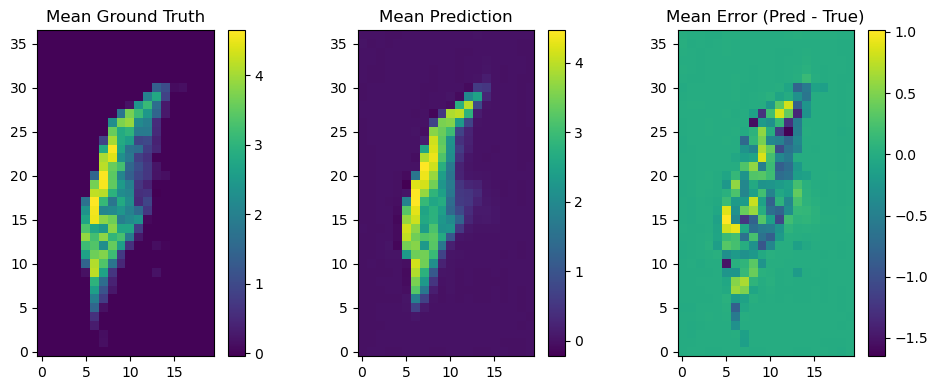

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))




ax1 = plt.subplot(1,3,1)
plt.title("Mean Ground Truth")
plt.imshow(mean_true)
plt.colorbar()
ax1.invert_yaxis()

ax2 = plt.subplot(1,3,2)
plt.title("Mean Prediction")
plt.imshow(mean_pred)
plt.colorbar()
ax2.invert_yaxis()

error = mean_pred - mean_true
ax3 = plt.subplot(1,3,3)
plt.title("Mean Error (Pred - True)")
plt.imshow(error)
plt.colorbar()
ax3.invert_yaxis()

plt.tight_layout()
plt.show()